# **Разведочный анализ данных для датасета User Knowledge Modeling**

In [ ]:
# 1. Загрузка библиотек и данных

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings('ignore')

# Загружаем данные из указанного URL
url = "https://raw.githubusercontent.com/yakushinav/omo/refs/heads/main/data/Data_User_Modeling_Dataset.csv"
df = pd.read_csv(url)

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
df.head()

Размер датасета: (258, 6)

Первые 5 строк:


,STG,SCG,STR,LPR,PEG,UNS
0,0.00,0.00,0.00,0.00,0.00,very_low
1,0.08,0.08,0.10,0.24,0.90,High
2,0.06,0.06,0.05,0.25,0.33,Low
3,0.10,0.10,0.15,0.65,0.30,Middle
4,0.08,0.08,0.08,0.98,0.24,Low


In [ ]:
# 2. Общая информация и пропуски

print("Типы данных и пропуски:")
df.info()

print("\nКоличество пропущенных значений по столбцам:")
df.isnull().sum()

Типы данных и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   STG     258 non-null    float64
 1   SCG     258 non-null    float64
 2   STR     258 non-null    float64
 3   LPR     258 non-null    float64
 4   PEG     258 non-null    float64
 5   UNS     258 non-null    object 
dtypes: float64(5), object(1)
memory usage: 12.2+ KB

Количество пропущенных значений по столбцам:


,0
STG,0
SCG,0
STR,0
LPR,0
PEG,0
UNS,0


Распределение классов:
UNS
Middle      88
Low         83
High        63
very_low    24
Name: count, dtype: int64

Относительные частоты:
UNS
Middle      0.341085
Low         0.321705
High        0.244186
very_low    0.093023
Name: proportion, dtype: float64


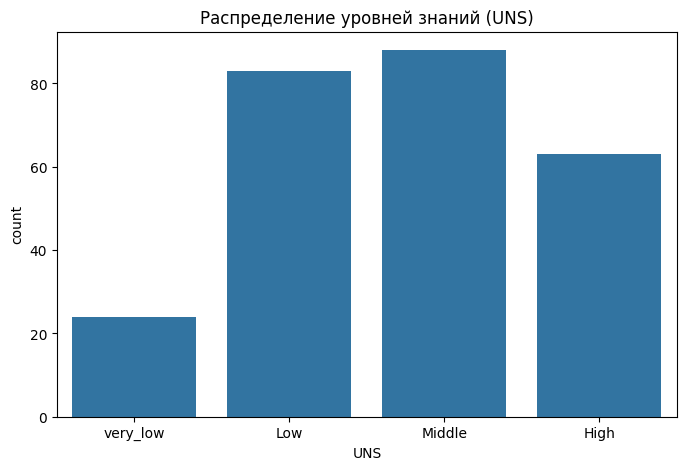

In [ ]:
# 3. Анализ целевой переменной

print("Распределение классов:")
print(df['UNS'].value_counts())

print("\nОтносительные частоты:")
print(df['UNS'].value_counts(normalize=True))

# Визуализация
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='UNS', order=['very_low', 'Low', 'Middle', 'High'])
plt.title('Распределение уровней знаний (UNS)')
plt.show()

In [ ]:
# 4. Описательная статистика числовых признаков

df.describe()

,STG,SCG,STR,LPR,PEG
count,258.000000,258.000000,258.000000,258.000000,258.000000
mean,0.371147,0.355674,0.468004,0.432713,0.458539
std,0.210271,0.211962,0.245940,0.248108,0.255211
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.240750,0.210000,0.291250,0.250000,0.250000
50%,0.327000,0.302500,0.490000,0.330000,0.500000
75%,0.495000,0.497500,0.690000,0.647500,0.660000
max,0.990000,0.900000,0.950000,0.990000,0.930000


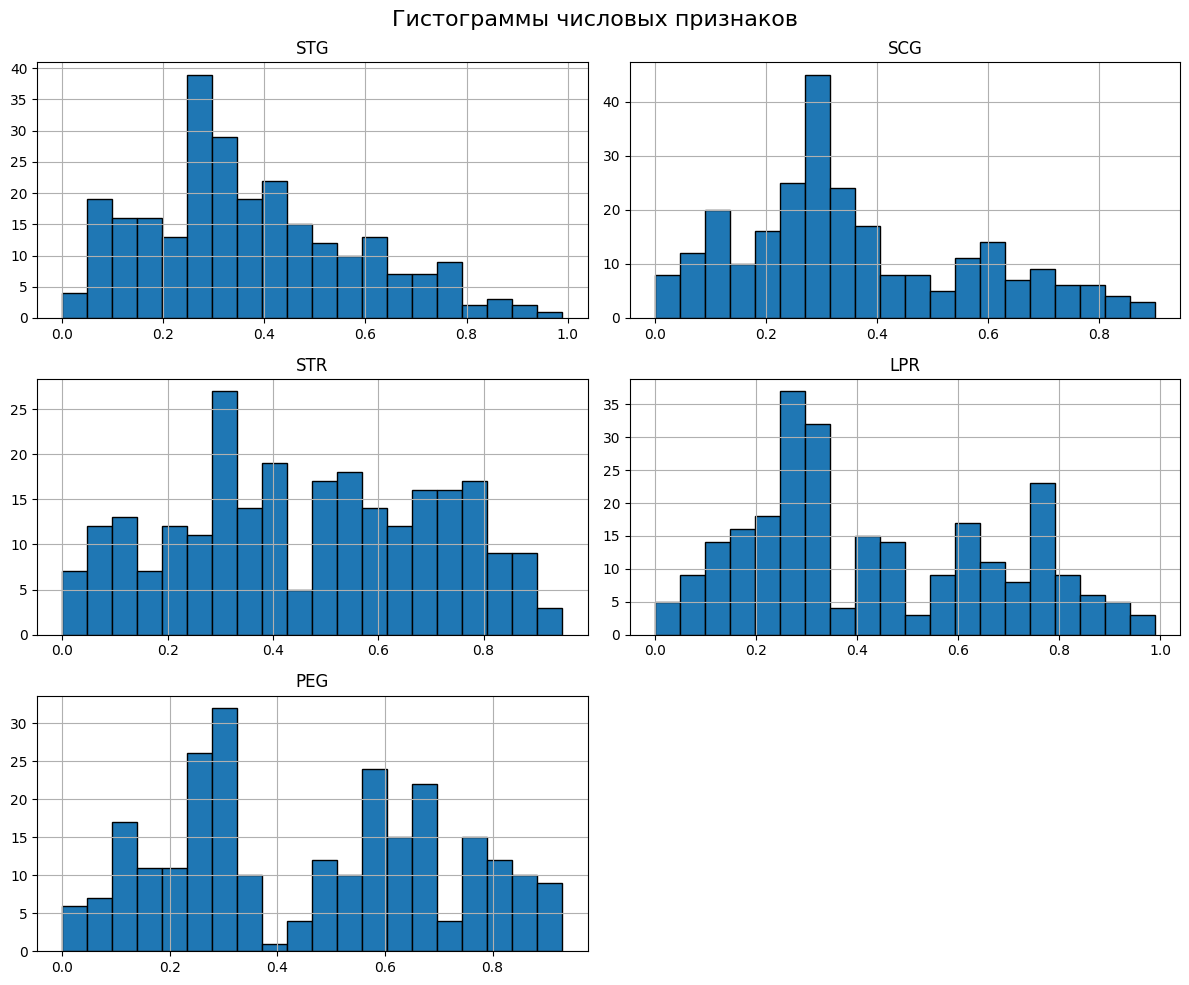

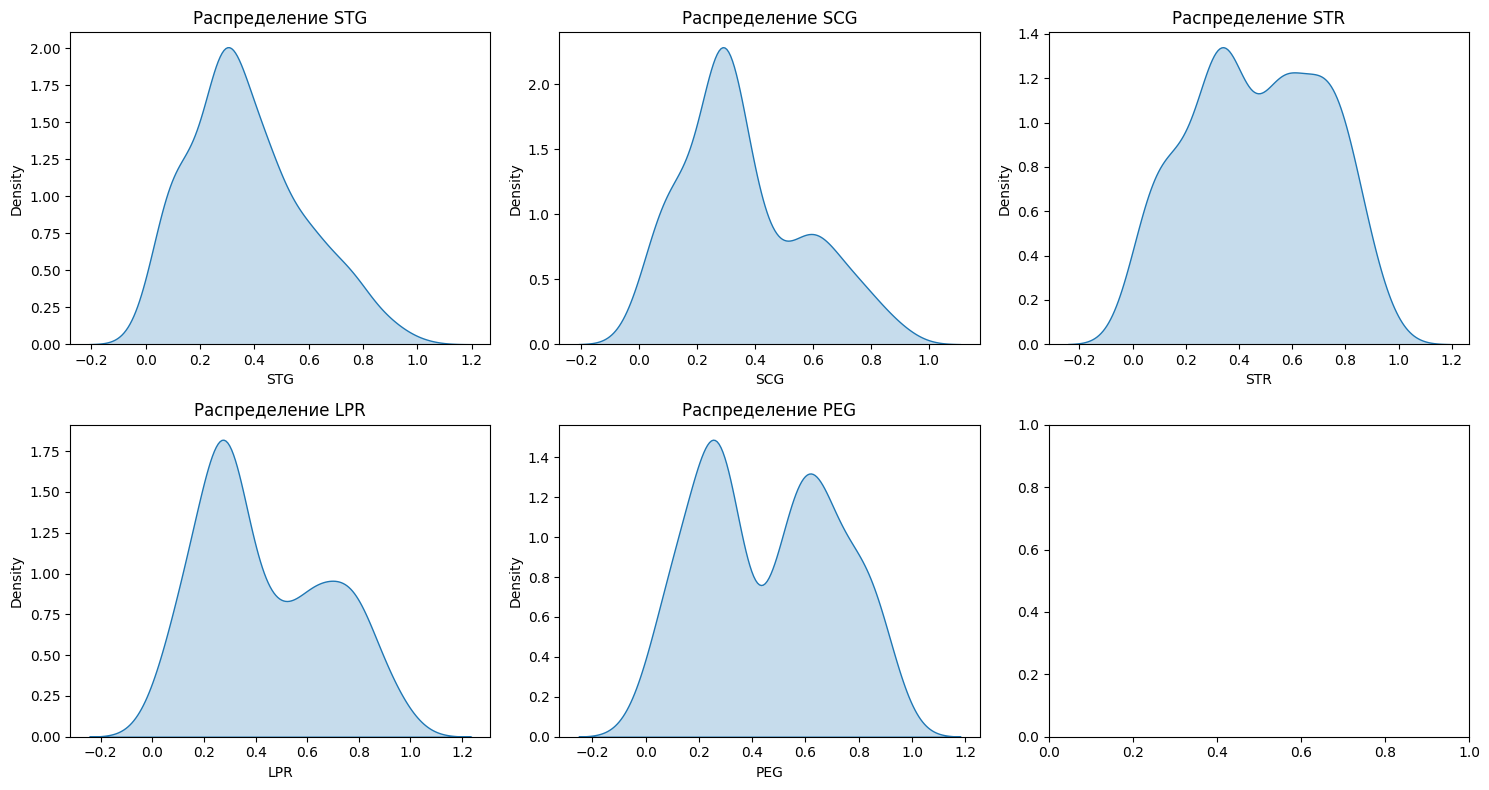

In [ ]:
# 5. Гистограммы и плотности распределения признаков

# Гистограммы
df.hist(figsize=(12,10), bins=20, edgecolor='black')
plt.suptitle('Гистограммы числовых признаков', fontsize=16)
plt.tight_layout()
plt.show()

# Графики плотности (KDE)
fig, axes = plt.subplots(2,3, figsize=(15,8))
features = ['STG', 'SCG', 'STR', 'LPR', 'PEG']
for i, col in enumerate(features):
    sns.kdeplot(data=df, x=col, ax=axes[i//3, i%3], fill=True)
    axes[i//3, i%3].set_title(f'Распределение {col}')
plt.tight_layout()
plt.show()

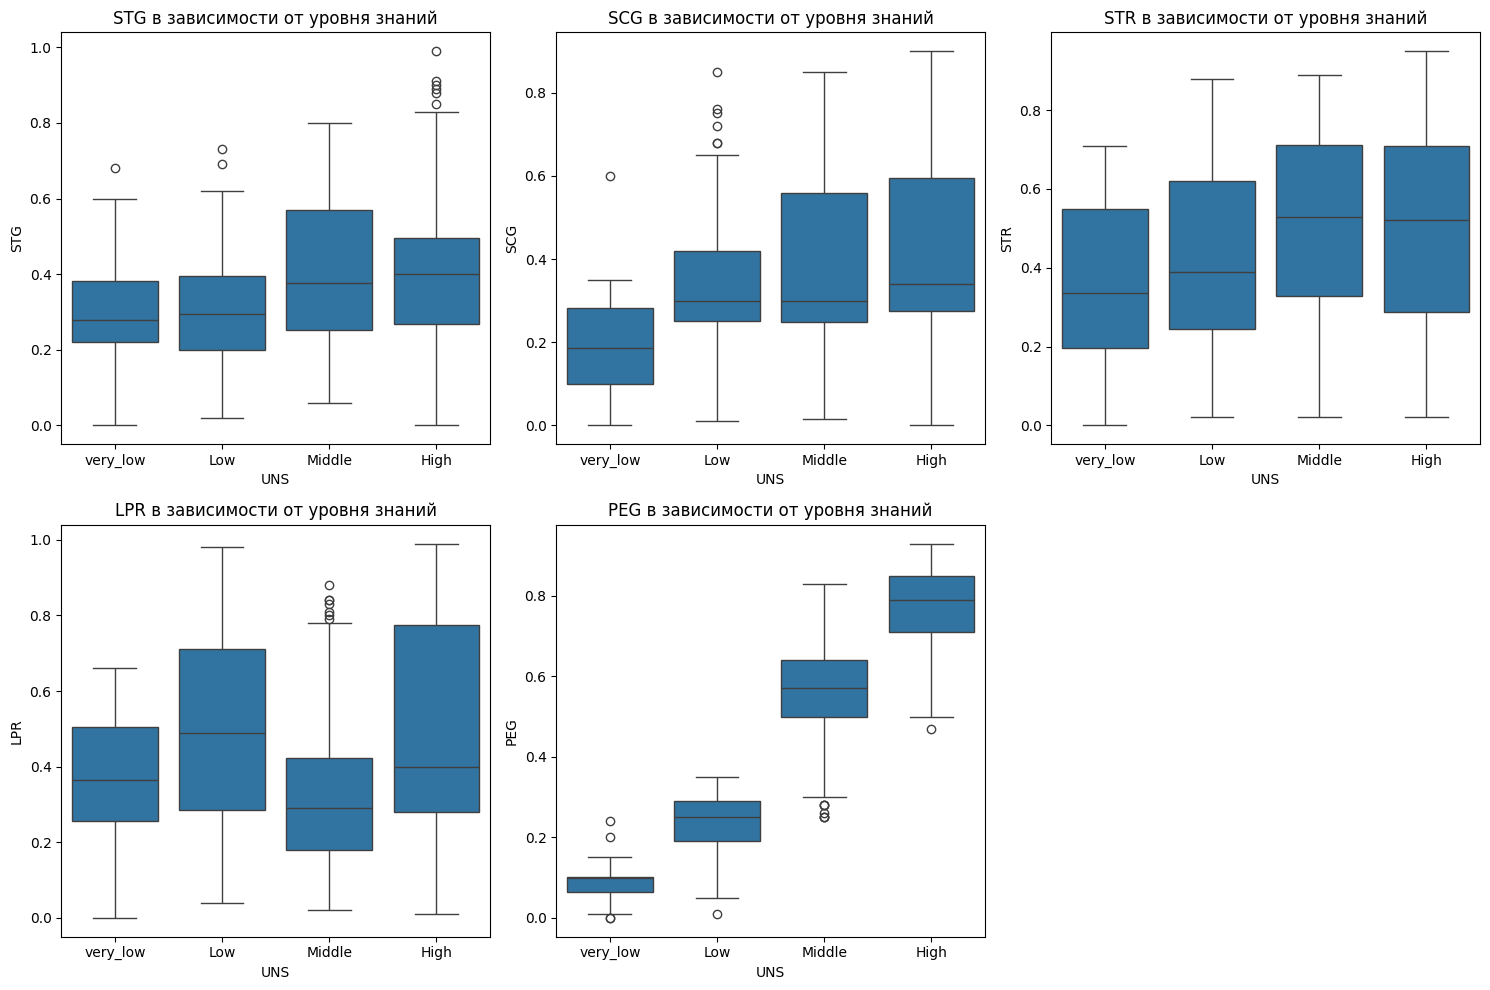

In [ ]:
# 6. Ящики с усами – сравнение признаков по уровням знаний

plt.figure(figsize=(15,10))
for i, col in enumerate(features):
    plt.subplot(2,3,i+1)
    sns.boxplot(data=df, x='UNS', y=col, order=['very_low','Low','Middle','High'])
    plt.title(f'{col} в зависимости от уровня знаний')
plt.tight_layout()
plt.show()

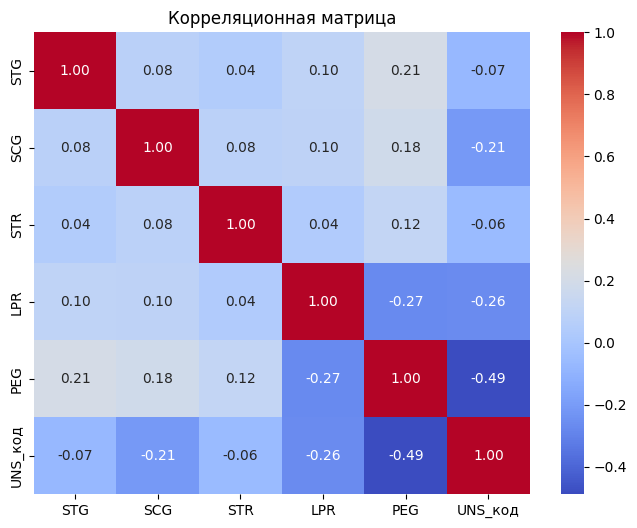

In [ ]:
# 7. Корреляционный анализ

# Кодируем целевую переменную для расчёта корреляции
le = LabelEncoder()
df['UNS_код'] = le.fit_transform(df['UNS'])  # very_low=0, Low=1, Middle=2, High=3

# Матрица корреляции
corr_matrix = df[features + ['UNS_код']].corr()

# Тепловая карта
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица')
plt.show()

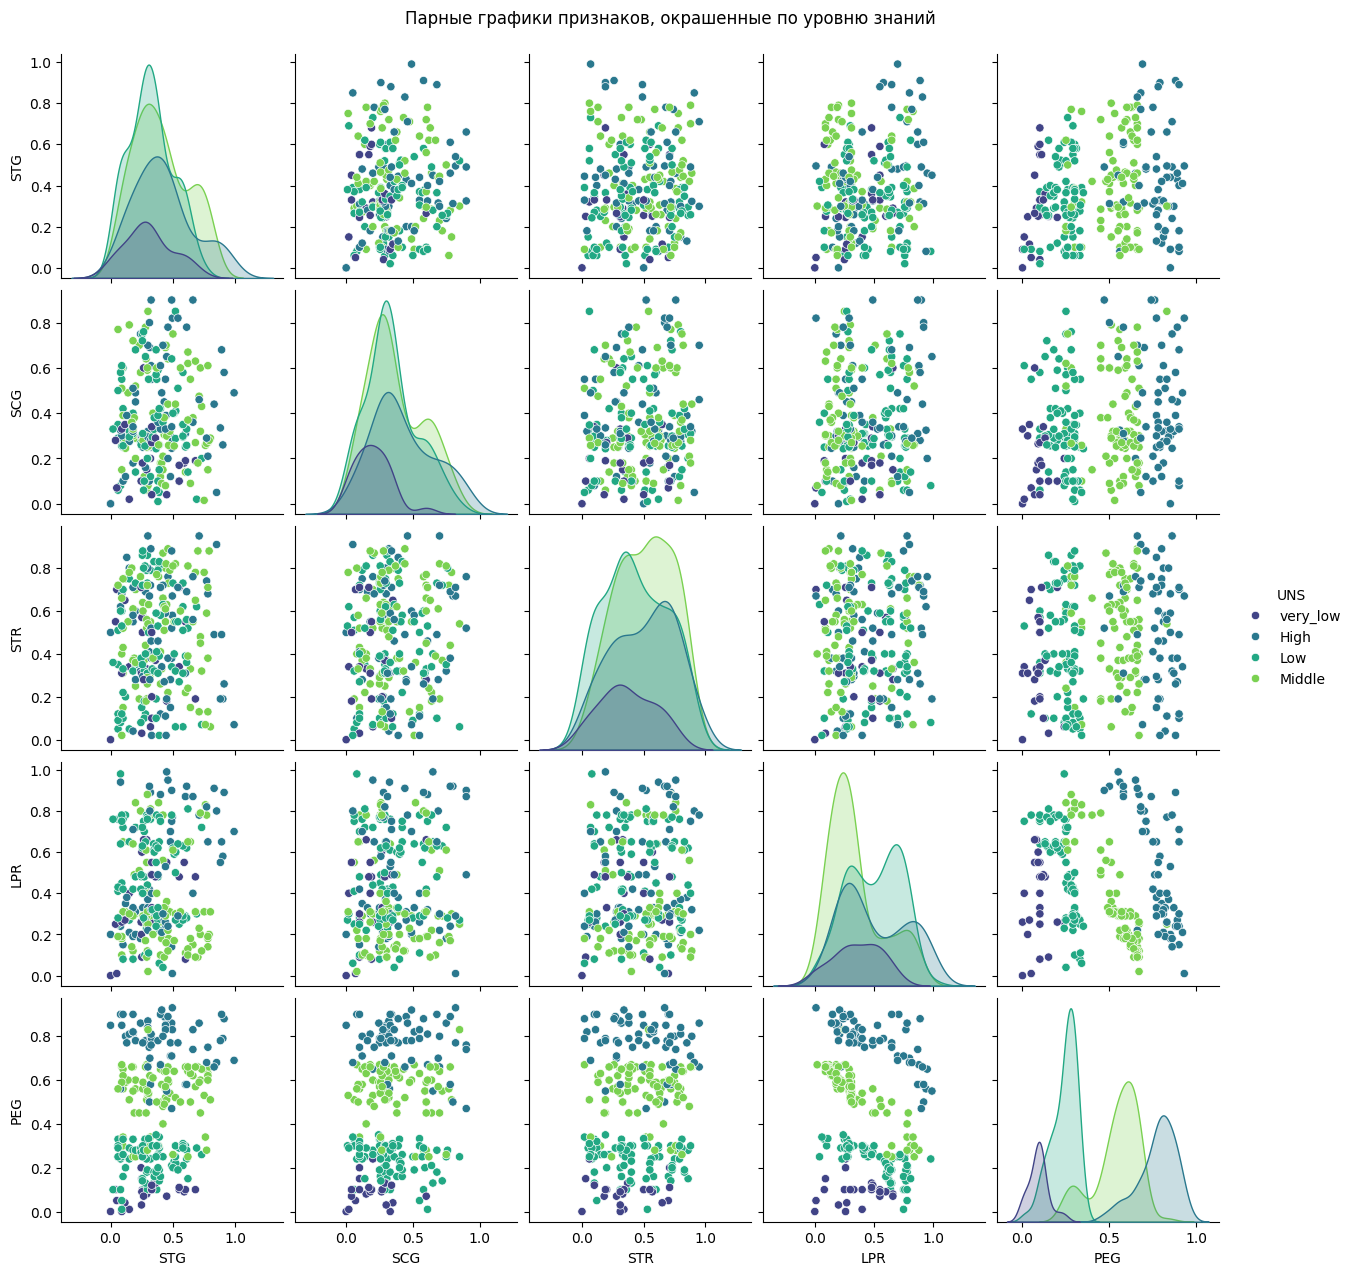

In [ ]:
# 8. Парные графики (pairplot) – разделение по классам

sns.pairplot(df, vars=features, hue='UNS', palette='viridis')
plt.suptitle('Парные графики признаков, окрашенные по уровню знаний', y=1.02)
plt.show()

In [ ]:
# 9. Проверка статистических гипотез

# Пример 1: t-критерий для среднего бала STG между группами Middle и High
# H0: Средние значения равны, H1: не равны

group_middle = df[df['UNS'] == 'Middle']['STG']
group_high = df[df['UNS'] == 'High']['STG']

stat, p = stats.ttest_ind(group_middle, group_high)
print(f'STG: Middle vs High -> t-статистика = {stat:.3f}, p-value = {p:.5f}')

alpha = 0.05
if p < alpha:
    print("Отклоняем H0: средние значимо отличаются")
else:
    print("Не отклоняем H0: различий нет")

# Пример 2: биномиальный тест для пропорций Low и Middle
# H0: вероятность встретить Low равна вероятности встретить Middle

from scipy.stats import binomtest
counts = df['UNS'].value_counts()
low_count = counts.get('Low', 0)
middle_count = counts.get('Middle', 0)
total = low_count + middle_count

res = binomtest(low_count, total, p=0.5)
print(f'\nБиномиальный тест для Low vs Middle: p-value = {res.pvalue:.3f}')
if res.pvalue > 0.05:
    print("Нет оснований отвергнуть H0: доли статистически равны")
else:
    print("Доли различаются")

STG: Middle vs High -> t-статистика = -0.584, p-value = 0.55998
Не отклоняем H0: различий нет

Биномиальный тест для Low vs Middle: p-value = 0.760
Нет оснований отвергнуть H0: доли статистически равны


# **Разведочный анализ данных для датасета Blood Transfusion**

In [ ]:
# 1. Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# для классификации
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# настройка отображения графиков
sns.set_style('whitegrid')

In [ ]:
# 2. Загрузка данных (UCI Machine Learning Repository)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/blood-transfusion/transfusion.data'
df = pd.read_csv(url)

# Посмотрим на первые строки
df.head()

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


In [ ]:
# 3. Информация о датасете
print("Размер данных:", df.shape)
df.info()

Размер данных: (748, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 5 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   Recency (months)                            748 non-null    int64
 1   Frequency (times)                           748 non-null    int64
 2   Monetary (c.c. blood)                       748 non-null    int64
 3   Time (months)                               748 non-null    int64
 4   whether he/she donated blood in March 2007  748 non-null    int64
dtypes: int64(5)
memory usage: 29.3 KB


In [ ]:
# 4. Проверка пропусков
print("Пропуски в каждом столбце:\n", df.isna().sum())

Пропуски в каждом столбце:
 Recency (months)                              0
Frequency (times)                             0
Monetary (c.c. blood)                         0
Time (months)                                 0
whether he/she donated blood in March 2007    0
dtype: int64


In [ ]:
# 5. Описательные статистики для числовых признаков
df.describe()

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007
count,748.000000,748.000000,748.000000,748.000000,748.000000
mean,9.506684,5.514706,1378.676471,34.282086,0.237968
std,8.095396,5.839307,1459.826781,24.376714,0.426124
min,0.000000,1.000000,250.000000,2.000000,0.000000
25%,2.750000,2.000000,500.000000,16.000000,0.000000
50%,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,14.000000,7.000000,1750.000000,50.000000,0.000000
max,74.000000,50.000000,12500.000000,98.000000,1.000000


In [ ]:
# 6. Переименуем столбцы для удобства (оригинальные названия длинные)
df.columns = ['Recency', 'Frequency', 'Monetary', 'Time', 'Donated_Mar2007']
# Recency – месяцы с последнего донации
# Frequency – общее число донаций
# Monetary – общий объём сданной крови (куб. см)
# Time – месяцы с первой донации
# Donated_Mar2007 – целевая переменная (1 = сдал кровь в марте 2007)
df.head()

,Recency,Frequency,Monetary,Time,Donated_Mar2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


In [ ]:
# 7. Анализ целевой переменной
print("Распределение классов:\n", df['Donated_Mar2007'].value_counts())
print("Доля сдавших кровь:", df['Donated_Mar2007'].mean())

Распределение классов:
 Donated_Mar2007
0    570
1    178
Name: count, dtype: int64
Доля сдавших кровь: 0.23796791443850268


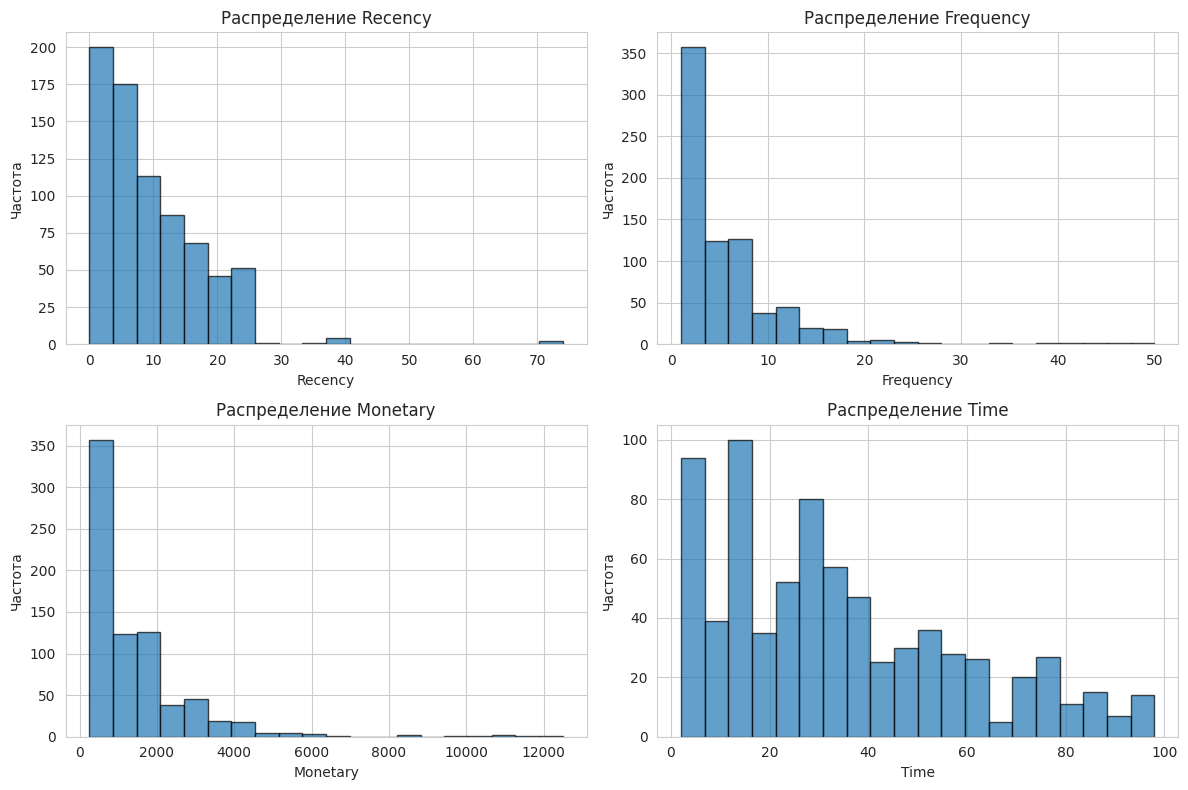

In [ ]:
# 8. Визуализация распределений признаков
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

features = ['Recency', 'Frequency', 'Monetary', 'Time']
for i, col in enumerate(features):
    axes[i].hist(df[col], bins=20, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Распределение {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

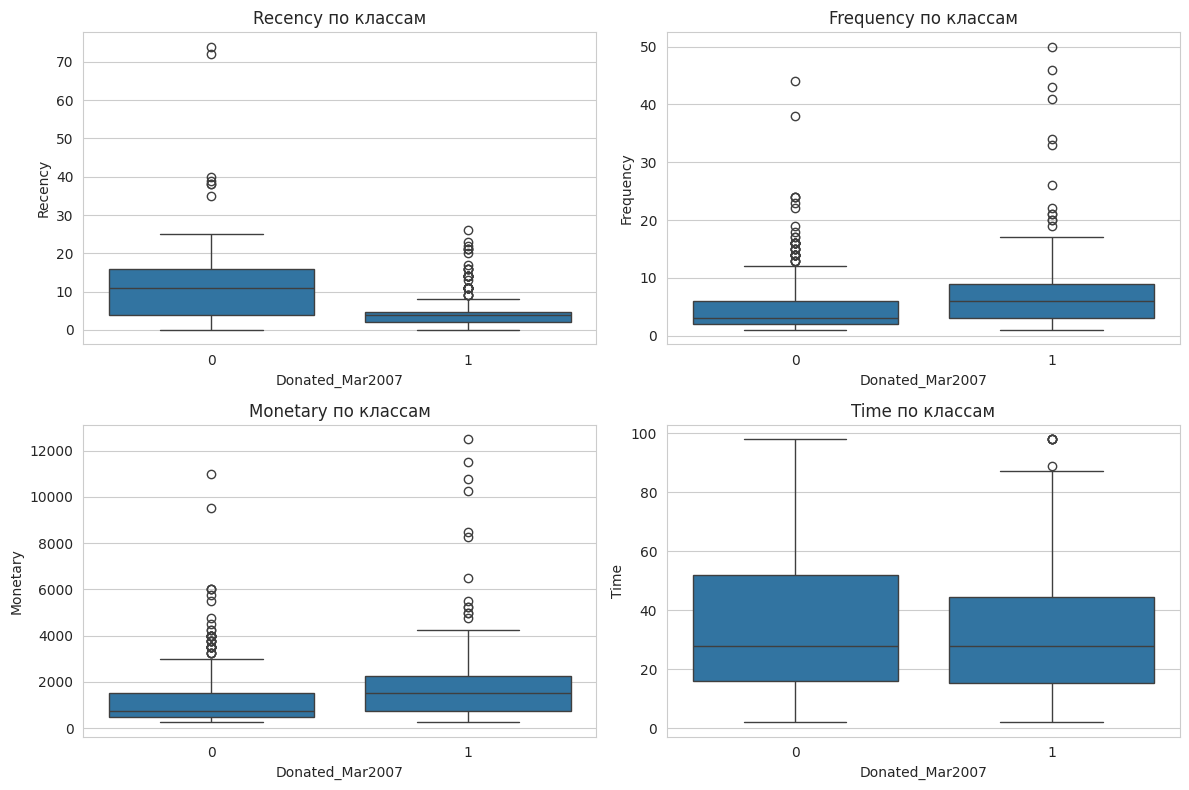

In [ ]:
# 9. Boxplot признаков в зависимости от класса
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, col in enumerate(features):
    sns.boxplot(x='Donated_Mar2007', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} по классам')

plt.tight_layout()
plt.show()

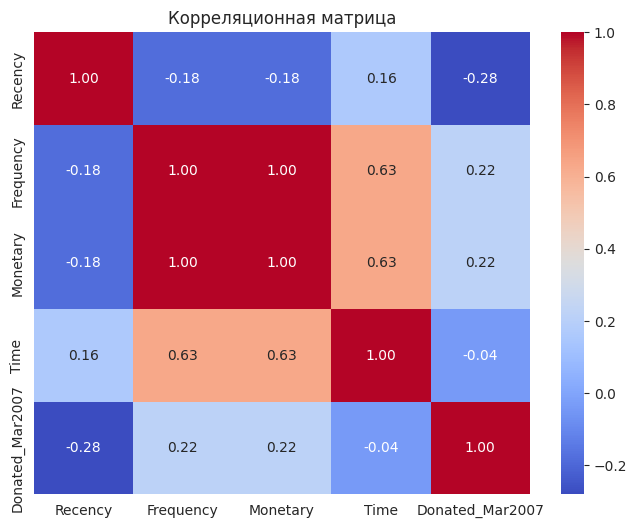

In [ ]:
# 10. Корреляционная матрица
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица')
plt.show()

In [ ]:
# 11. Группировка по целевому признаку – средние значения
grouped = df.groupby('Donated_Mar2007').agg(['mean', 'median', 'std'])
grouped.round(2)

Recency              Frequency              Monetary          \
                   mean median   std      mean median   std     mean  median   
Donated_Mar2007                                                                
0                 10.77   11.0  8.43       4.8    3.0  4.75  1200.44   750.0   
1                  5.46    4.0  5.17       7.8    6.0  8.04  1949.44  1500.0   

                           Time                
                     std   mean median    std  
Donated_Mar2007                                
0                1186.69  34.77   28.0  24.61  
1                2009.22  32.72   28.0  23.63

In [ ]:
# 12. Фильтрация – например, люди, сдавшие кровь недавно (Recency <= 6 месяцев)
recent_donors = df[df['Recency'] <= 6]
print("Количество недавних доноров:", len(recent_donors))
print("Доля сдавших в марте среди них:", recent_donors['Donated_Mar2007'].mean())

Количество недавних доноров: 367
Доля сдавших в марте среди них: 0.37329700272479566


In [ ]:
# 13. Подготовка к классификации
X = df[['Recency', 'Frequency', 'Monetary', 'Time']]
y = df['Donated_Mar2007']

# Разделение на обучающую и тестовую выборки (70% / 30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
# 14. Логистическая регрессия (простая классификация)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Точность на тесте:", accuracy_score(y_test, y_pred))
print("\nМатрица ошибок:\n", confusion_matrix(y_test, y_pred))
print("\nОтчёт о классификации:\n", classification_report(y_test, y_pred))

Точность на тесте: 0.7688888888888888

Матрица ошибок:
 [[168   3]
 [ 49   5]]

Отчёт о классификации:
               precision    recall  f1-score   support

           0       0.77      0.98      0.87       171
           1       0.62      0.09      0.16        54

    accuracy                           0.77       225
   macro avg       0.70      0.54      0.51       225
weighted avg       0.74      0.77      0.70       225



In [ ]:
# 15. Дерево решений для сравнения
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("Точность дерева решений:", accuracy_score(y_test, y_pred_tree))

Точность дерева решений: 0.7866666666666666


# **Разведочный анализ данных для датасета Somerville Happiness Survey 2015**

In [ ]:
# 1. Загрузка библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 2. Загрузка данных
url = "https://raw.githubusercontent.com/yakushinav/omo/refs/heads/main/data/SomervilleHappinessSurvey2015.csv"
df = pd.read_csv(url)

print("Размер данных:", df.shape)
df.head()

Размер данных: (143, 7)


,D,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [ ]:
# 3. Первичная информация о данных
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   D       143 non-null    int64
 1   X1      143 non-null    int64
 2   X2      143 non-null    int64
 3   X3      143 non-null    int64
 4   X4      143 non-null    int64
 5   X5      143 non-null    int64
 6   X6      143 non-null    int64
dtypes: int64(7)
memory usage: 7.9 KB


,D,X1,X2,X3,X4,X5,X6
count,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000
mean,0.538462,4.314685,2.538462,3.265734,3.699301,3.615385,4.216783
std,0.500271,0.799820,1.118155,0.992586,0.888383,1.131639,0.848693
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,4.000000,2.000000,3.000000,3.000000,3.000000,4.000000
50%,1.000000,5.000000,3.000000,3.000000,4.000000,4.000000,4.000000
75%,1.000000,5.000000,3.000000,4.000000,4.000000,4.000000,5.000000
max,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


Доля счастливых и несчастливых:
D
1    0.538462
0    0.461538
Name: proportion, dtype: float64


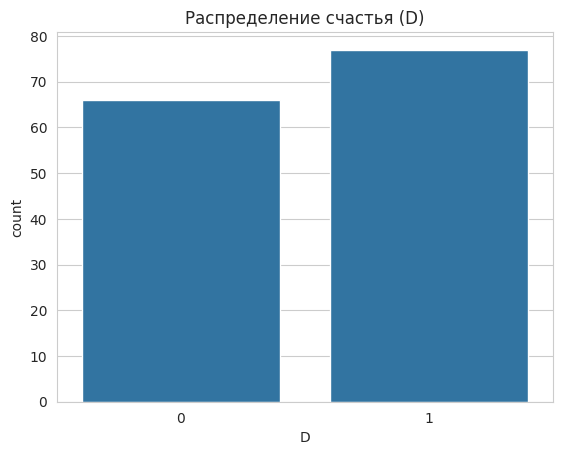

In [ ]:
# 4. Распределение целевой переменной (счастье)
print("Доля счастливых и несчастливых:")
print(df['D'].value_counts(normalize=True))

sns.countplot(x='D', data=df)
plt.title("Распределение счастья (D)")
plt.show()

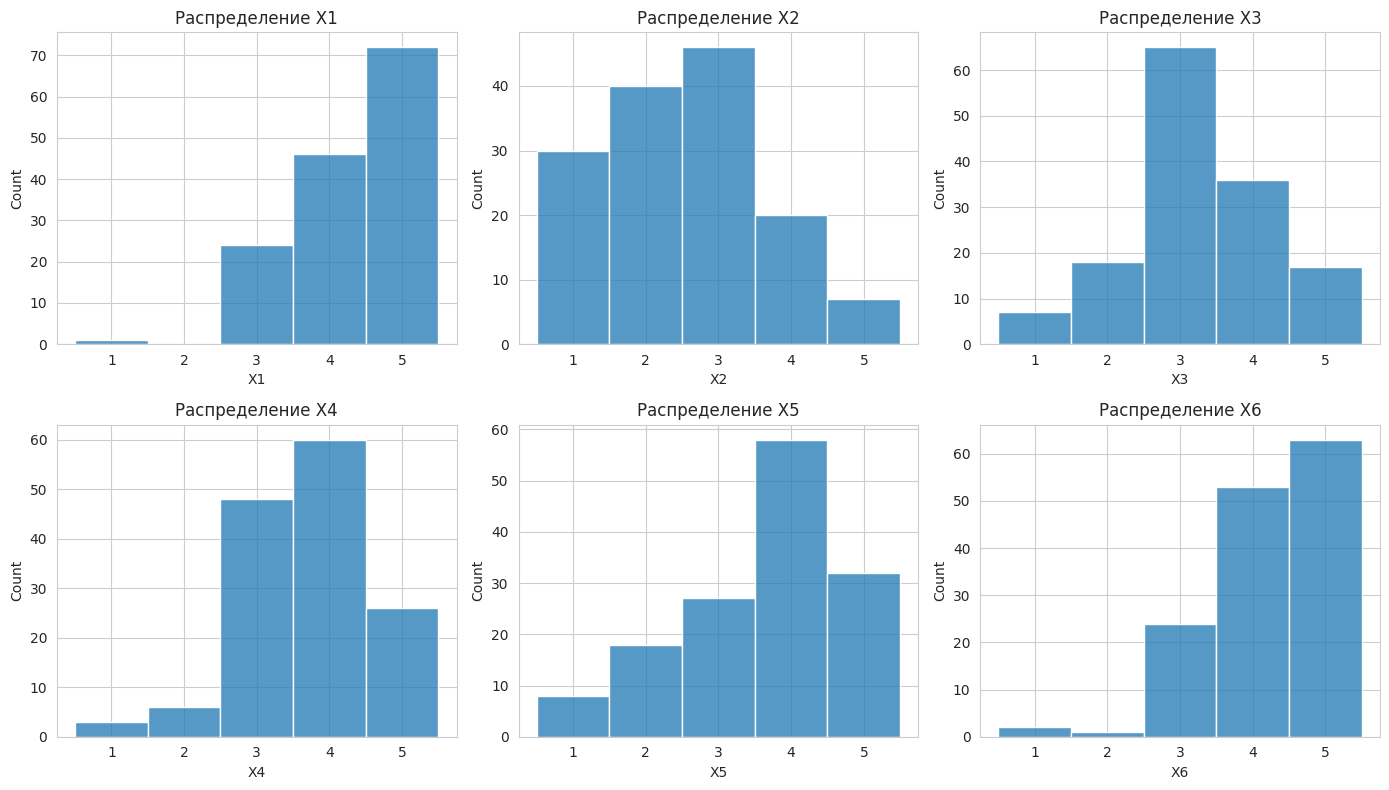

In [ ]:
# 5. Распределение каждого признака (гистограммы)
features = ['X1','X2','X3','X4','X5','X6']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, f in enumerate(features):
    row, col = i//3, i%3
    sns.histplot(df[f], bins=5, discrete=True, ax=axes[row,col])
    axes[row,col].set_title(f'Распределение {f}')

plt.tight_layout()
plt.show()

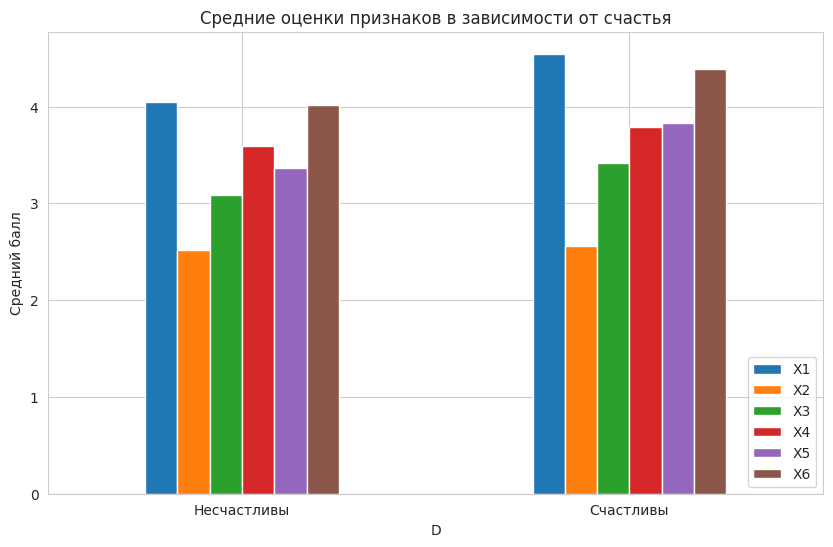

In [ ]:
# 6. Сравнение средних оценок у счастливых и несчастливых
df.groupby('D')[features].mean().plot(kind='bar', figsize=(10,6))
plt.title('Средние оценки признаков в зависимости от счастья')
plt.ylabel('Средний балл')
plt.xticks([0,1], ['Несчастливы','Счастливы'], rotation=0)
plt.legend(loc='lower right')
plt.show()

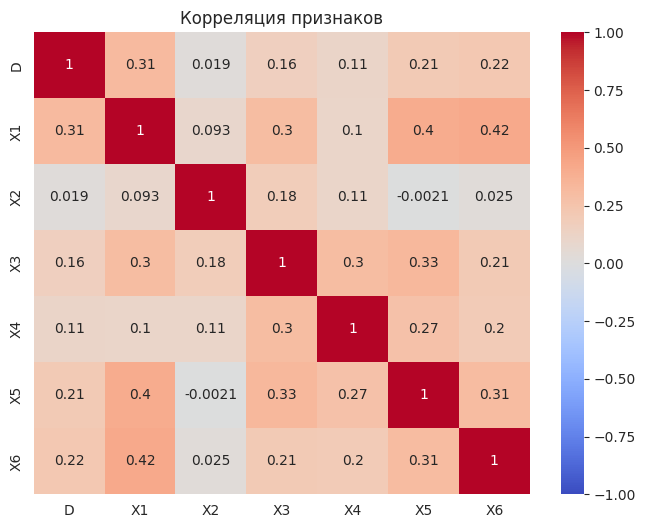

In [ ]:
# 7. Корреляционная матрица
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляция признаков')
plt.show()

In [ ]:
# 8. t-критерий для доверия полиции (X4)
from scipy.stats import ttest_ind

happy = df[df['D']==1]['X4']
unhappy = df[df['D']==0]['X4']

stat, p = ttest_ind(happy, unhappy)
print(f"t-статистика = {stat:.3f}, p-значение = {p:.4f}")

alpha = 0.05
if p < alpha:
    print("Отклонить H0: доверие полиции значимо отличается между группами")
else:
    print("Принять H0: различий нет")

t-статистика = 1.355, p-значение = 0.1777
Принять H0: различий нет


In [ ]:
# 9. Тест Шапиро-Уилка на нормальность (для признака X2)
from scipy.stats import shapiro

stat, p = shapiro(df['X2'])
print(f'Shapiro: статистика={stat:.3f}, p={p:.3f}')
if p < 0.05:
    print('Отклонить гипотезу о нормальности (распределение не нормально)')
else:
    print('Принять гипотезу о нормальности')

Shapiro: статистика=0.902, p=0.000
Отклонить гипотезу о нормальности (распределение не нормально)


In [ ]:
# 10. Биномиальный тест: равна ли доля счастливых 0.5?
from scipy.stats import binomtest

happy_count = df['D'].sum()
total = len(df)
res = binomtest(happy_count, total, p=0.5)
print(f"Доля счастливых: {happy_count/total:.2f}")
print(f"p-значение биномиального теста: {res.pvalue:.4f}")

if res.pvalue > 0.05:
    print("H0 не отвергается: доля счастливых статистически не отличается от 0.5")
else:
    print("H0 отвергается: доля отличается от 0.5")

Доля счастливых: 0.54
p-значение биномиального теста: 0.4031
H0 не отвергается: доля счастливых статистически не отличается от 0.5


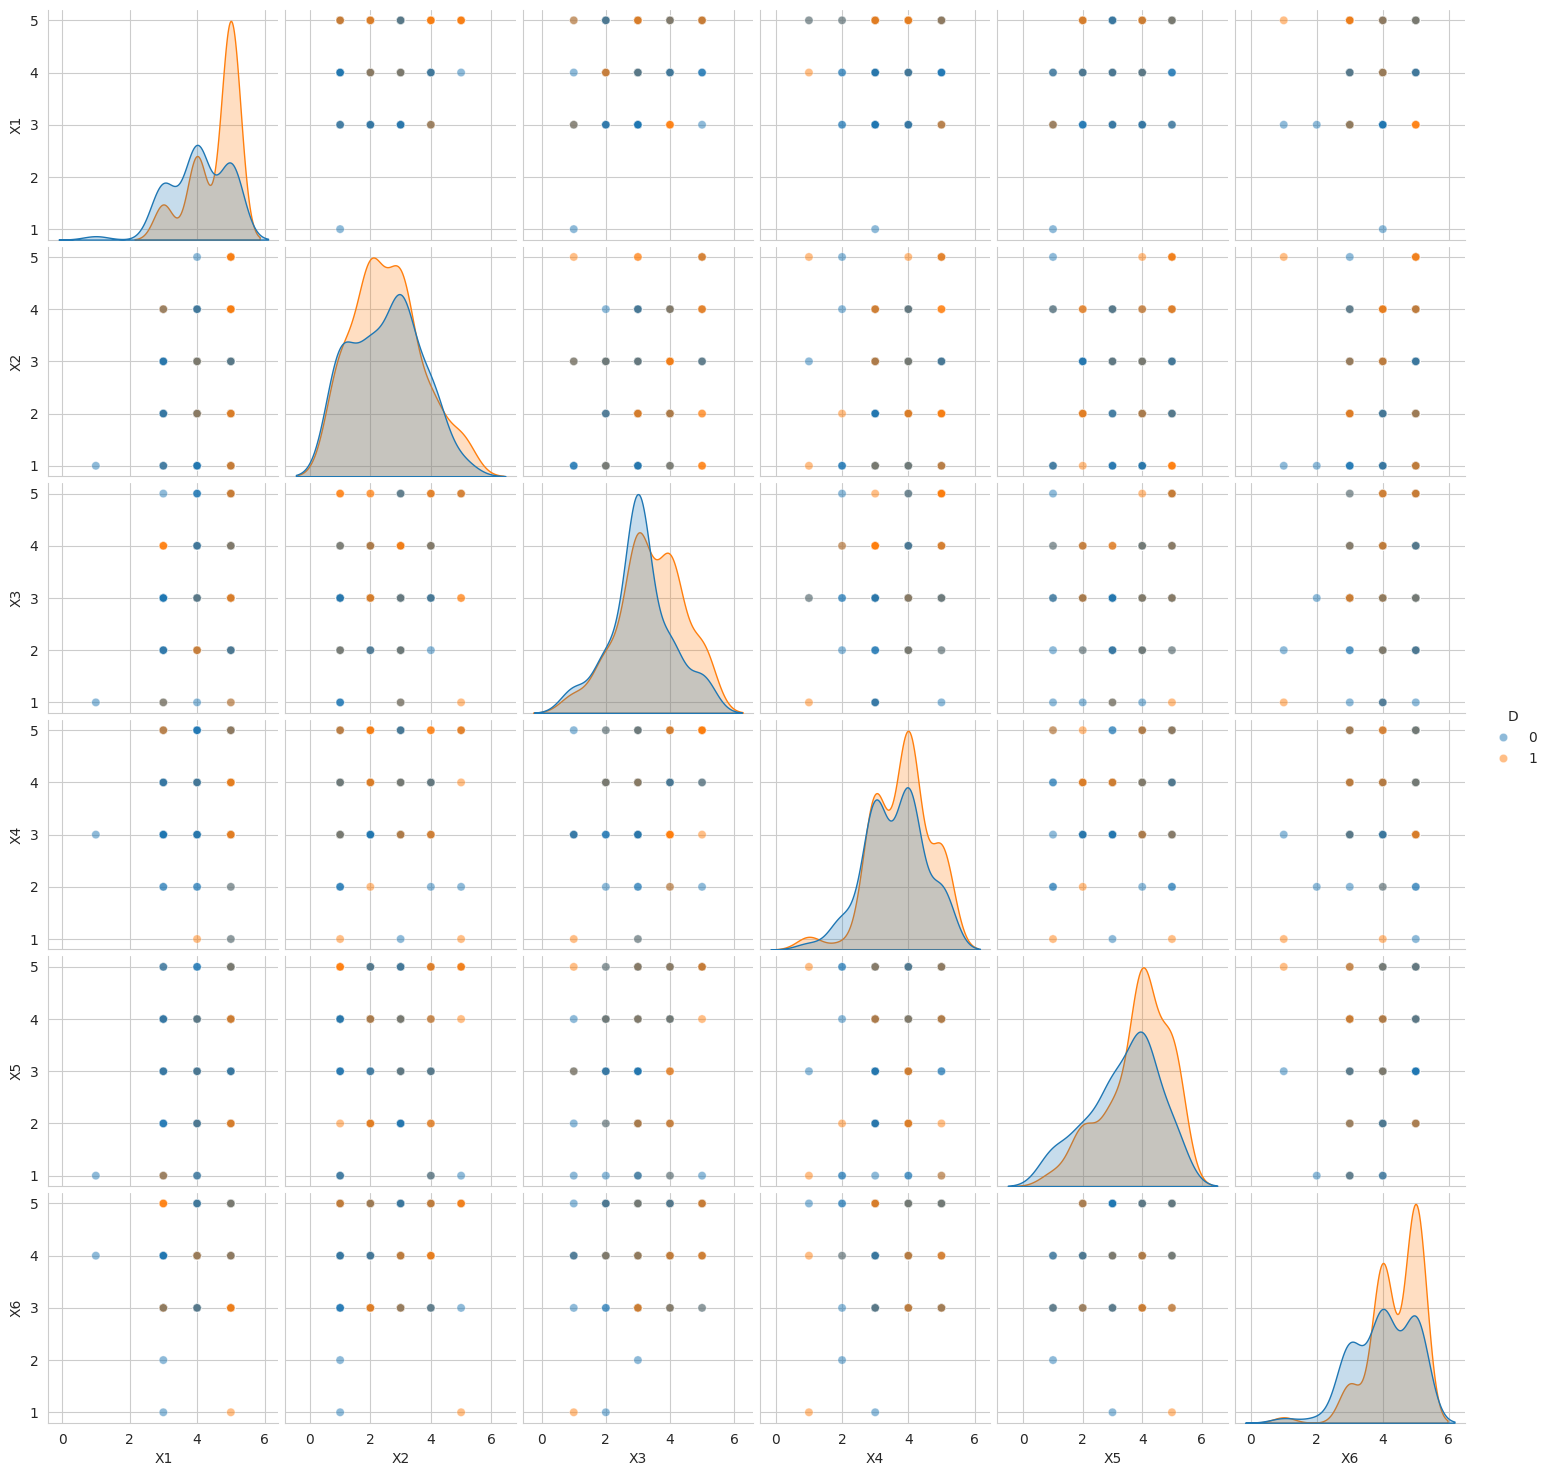

In [ ]:
# 11. Парный график (pairplot) с разделением по счастью
sns.pairplot(df, hue='D', diag_kind='kde', plot_kws={'alpha':0.5})
plt.show()

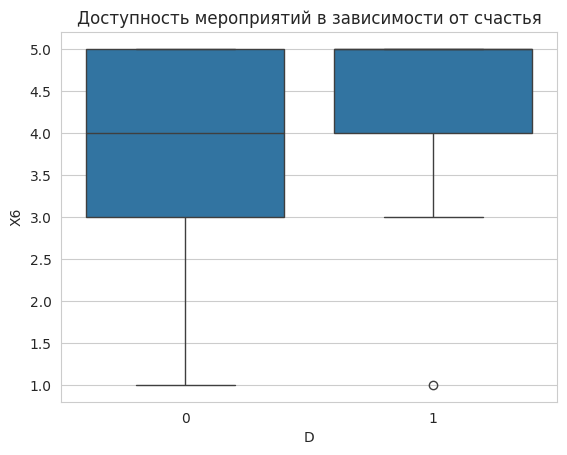

In [ ]:
# 12. Ящик с усами для доступности мероприятий (X6)
sns.boxplot(x='D', y='X6', data=df)
plt.title('Доступность мероприятий в зависимости от счастья')
plt.show()

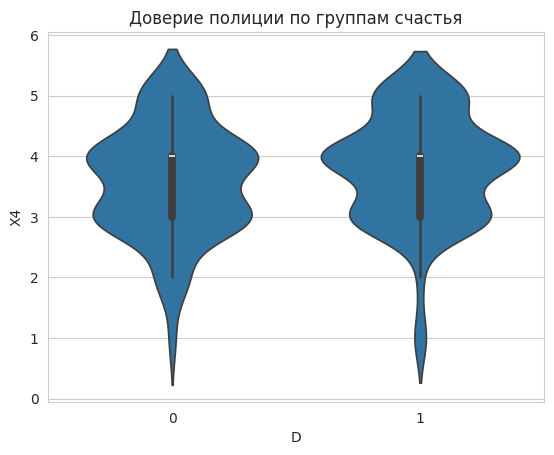

In [ ]:
# 13. Скрипичный график для доверия полиции (X4)
sns.violinplot(y=df['X4'], x=df['D'])
plt.title('Доверие полиции по группам счастья')
plt.show()

In [ ]:
# 14. Логистическая регрессия (базовый классификатор)
X = df[['X1','X2','X3','X4','X5','X6']]
y = df['D']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred_log = logreg.predict(X_test)

print("Точность логистической регрессии:", accuracy_score(y_test, y_pred_log))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred_log))

Точность логистической регрессии: 0.5517241379310345
Матрица ошибок:
[[ 5 10]
 [ 3 11]]


In [ ]:
# 15. Дерево решений для сравнения
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("Точность дерева решений:", accuracy_score(y_test, y_pred_tree))

Точность дерева решений: 0.5862068965517241


In [ ]:
# 16. Сравнение моделей (необязательно)
print("\nСравнение точности:")
print(f"Логистическая регрессия: {accuracy_score(y_test, y_pred_log):.3f}")
print(f"Дерево решений (max_depth=3): {accuracy_score(y_test, y_pred_tree):.3f}")


Сравнение точности:
Логистическая регрессия: 0.552
Дерево решений (max_depth=3): 0.586
